### MAP THE IMAGES

In [ ]:
import os
import shutil
from datetime import datetime, timedelta

# Paths to wind data and BT1 folders
wind_data_path = r"C:/Users/Sahil/SIH2024/V2/wind/wind"
bt_data_path = r"C:/Users/Sahil/SIH2024/V2/BT1/Jan"
output_folder = r"C:/Users/Sahil/SIH2024/V3/output"  # Folder where the images will be copied

# Function to extract the date from wind image filename
def get_wind_date(wind_filename):
    try:
        day_str = wind_filename.split('_')[1]  # Extract "2024099"
        year = int(day_str[:4])  # Extract year (2024)
        day_of_year = int(day_str[4:])  # Extract day of the year (099)
        date = datetime(year, 1, 1) + timedelta(days=day_of_year - 1)  # Calculate the date
        return f"Day{day_of_year:03d}", date.strftime('%d_%b_%Y')  # Return (DayNNN, day_month_year)
    except IndexError:
        print(f"Error parsing wind filename: {wind_filename}")
        return None, None  # Handle error case

# Function to extract day and month from BT image filename
def get_bt_day_and_month(bt_filename):
    try:
        parts = bt_filename.split('_')
        if len(parts) > 1:
            day_str = parts[1][0:2]  # Extract "30"
            month_str = parts[1][2:5]  # Extract "JAN"
            year_str = parts[1][5:9]  # Extract "2024"
            bt_datetime = datetime.strptime(f'{day_str}{month_str}{year_str}', '%d%b%Y')
            day_of_year = (bt_datetime - datetime(bt_datetime.year, 1, 1)).days + 1
            return f"Day{day_of_year:03d}", bt_datetime.strftime('%d_%b_%Y')  # Return (DayNNN, day_month_year)
        else:
            print(f"Invalid BT filename format: {bt_filename}")
            return None, None
    except (IndexError, ValueError) as e:
        print(f"Error parsing BT filename: {bt_filename} ({e})")
        return None, None

# Function to check if a file is an image
def is_image_file(filename):
    return filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))

# Function to map wind images to BT images by day
def map_wind_to_bt(wind_data_path, bt_data_path):
    mapping = {}

    # List all wind images and sort them by date
    wind_images = [f for f in os.listdir(wind_data_path) if is_image_file(f)]
    for wind_file in wind_images:
        wind_day_str, wind_full_date = get_wind_date(wind_file)
        if wind_day_str and wind_full_date:
            if wind_day_str not in mapping:
                mapping[wind_day_str] = []
            mapping[wind_day_str].append((os.path.join(wind_data_path, wind_file), wind_full_date))

    return mapping

# Function to create day-wise folders and copy images
def create_day_folders_and_copy_images(mapping, bt_data_path, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)  # Create the output folder if it doesn't exist

    # Iterate over each day in the mapping
    for day_str, wind_images in mapping.items():
        # Create the folder for the specific day (e.g., "Day001")
        day_folder_path = os.path.join(output_folder, day_str)

        if not os.path.exists(day_folder_path):
            os.makedirs(day_folder_path)

        # Copy and rename the wind images to the day folder
        for wind_image, wind_full_date in wind_images:
            # Extract filename and extension
            filename, ext = os.path.splitext(os.path.basename(wind_image))
            # Rename the file
            new_filename = f"{filename[:11]}_{wind_full_date.replace('_', '')}{ext}"
            shutil.copy(wind_image, os.path.join(day_folder_path, new_filename))

        # Copy the BT images for the same day to the day folder
        for month_folder in os.listdir(bt_data_path):
            month_path = os.path.join(bt_data_path, month_folder)
            if os.path.isdir(month_path):
                bt_images = [f for f in os.listdir(month_path) if is_image_file(f)]
                for bt_image in bt_images:
                    bt_day_str, bt_full_date = get_bt_day_and_month(bt_image)
                    if bt_day_str == day_str:
                        shutil.copy(os.path.join(month_path, bt_image), day_folder_path)

# Call the function to get the mapping
wind_to_bt_mapping = map_wind_to_bt(wind_data_path, bt_data_path)

# Create the day-wise folders, and copy and rename the images
create_day_folders_and_copy_images(wind_to_bt_mapping, bt_data_path, output_folder)

print("Images have been copied to the respective day folders with updated filenames.")


### CREATING NUMPY array still not dyanmic



In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

image_path = 'Winds.jpg'  
image = cv2.imread(image_path)


height, width = image.shape[:2]

#cropping size
crop_percentage = 0.6

crop_width = int(width * crop_percentage)
crop_height = int(height * crop_percentage)

start_x = (width - crop_width) // 2
start_y = (height - crop_height) // 2

image = image[start_y+100:start_y + crop_height - 350, start_x * 3 + 20: start_x + crop_width - 100]

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

arrow_info_array = np.zeros((gray_image.shape[0], gray_image.shape[1], 3))  # 3 channels: i, j, size

template_paths = ['Arrows.jpg', 'Arrows2.jpg']

best_match_locations = []
best_match_values = []

angles = range(0, 360, 10)

white_pixel_threshold = 0.05

for template_path in template_paths:
    template = cv2.imread(template_path, 0)

    h, w = template.shape[:2]

    for angle in angles:
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1)
        rotated_template = cv2.warpAffine(template, M, (w, h))

        result = cv2.matchTemplate(gray_image, rotated_template, cv2.TM_CCOEFF_NORMED)

        threshold = 0.58
        locations = np.where(result >= threshold)

        for pt in zip(*locations[::-1]):
            x1, y1 = pt[0], pt[1]
            x2, y2 = x1 + w, y1 + h

            roi = gray_image[y1:y2, x1:x2]
            white_pixel_count = np.sum(roi == 255)
            total_pixels = roi.size

            white_pixel_ratio = white_pixel_count / total_pixels

            if white_pixel_ratio < white_pixel_threshold:
                best_match_locations.append(pt)
                best_match_values.append(result[pt[1], pt[0]])

                cv2.rectangle(image, pt, (x2, y2), (0, 255, 0), 2)

                i_component = np.cos(np.deg2rad(angle))  # Horizontal direction
                j_component = np.sin(np.deg2rad(angle))  # Vertical direction

                arrow_size = np.sqrt(w ** 2 + h ** 2)

                arrow_info_array[y1:y2, x1:x2, 0] = i_component  # i-component
                arrow_info_array[y1:y2, x1:x2, 1] = j_component  # j-component
                arrow_info_array[y1:y2, x1:x2, 2] = arrow_size   # size of the arrow

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Detected Arrows with i, j Components and Sizes')
plt.axis('off')
plt.show()

output_image_path = 'detected_arrows_image_resized.jpg'
cv2.imwrite(output_image_path, image)
print(f"Resized image saved as '{output_image_path}'")

image_path = 'output.jpg'
image = cv2.imread(image_path)

resized_image = cv2.resize(image, (796, 859))

output_image_path = 'detected_arrows_image_resized.jpg'
cv2.imwrite(output_image_path, resized_image)
print(f"Resized image saved as '{output_image_path}'")

resized_arrow_info_array = np.zeros((859, 796, 3))  # New 796x859 array with 3 channels
for channel in range(3):
    resized_arrow_info_array[:, :, channel] = cv2.resize(arrow_info_array[:, :, channel], (796, 859))


np.save('resized_arrow_info_array.npy', resized_arrow_info_array)
print("Resized arrow information array saved as 'resized_arrow_info_array.npy'")


### organising numpy arrays

In [6]:
import os
import shutil
from datetime import datetime, timedelta

# Paths to the folder containing .npy files and the output folder
npy_data_path = r"C:/Users/Sahil/SIH2024/V2/wind_arrays"  # Replace with the path to your .npy files
output_folder = r"C:/Users/Sahil/SIH2024/V3/mapped_output"  # Replace with the desired output folder path

# Function to extract the day number from the .npy filename
def get_day_number_from_npy(npy_filename):
    try:
        day_str = npy_filename.split('_')[1]  # Extract the day number (e.g., "2024121")
        year = int(day_str[:4])  # Extract year (e.g., 2024)
        day_of_year = int(day_str[4:])  # Extract day of the year (e.g., 121)
        return f"Day_{day_of_year:03d}"  # Return formatted day string (e.g., "Day_121")
    except IndexError:
        print(f"Error parsing .npy filename: {npy_filename}")
        return None  # Handle error case

# Function to organize .npy files into day-specific folders
def organize_npy_files(npy_data_path, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)  # Create the output folder if it doesn't exist

    # List all .npy files in the source folder
    npy_files = [f for f in os.listdir(npy_data_path) if f.lower().endswith('.npy')]

    # Process each .npy file
    for npy_file in npy_files:
        day_folder_name = get_day_number_from_npy(npy_file)
        if day_folder_name:
            day_folder_path = os.path.join(output_folder, day_folder_name)
            
            if not os.path.exists(day_folder_path):
                os.makedirs(day_folder_path)  # Create the folder for the specific day

            # Move the .npy file to the day-specific folder
            shutil.move(os.path.join(npy_data_path, npy_file), os.path.join(day_folder_path, npy_file))

# Call the function to organize the .npy files
organize_npy_files(npy_data_path, output_folder)

print("All .npy files have been organized into their respective day-specific folders.")


All .npy files have been organized into their respective day-specific folders.


### CLOUD EXTRACTION MASKING


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Function to process a single image
def process_image(image_path, output_path):
    # Load the thermal image
    thermal_image = cv2.imread(image_path)
    
    # Trim the top part of the image
    cropped_image = thermal_image[100:, :]  # Adjust the cropping as needed
    
    # Convert to HSV for better color segmentation
    hsv_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2HSV)
    
    # Define HSV ranges for different features
    ranges = {
        "blue": ([90, 50, 50], [130, 255, 255]),        # Blues
        "yellow": ([25, 100, 100], [30, 255, 255]),    # Bright yellows (avoiding dark ochre)
        "green": ([35, 50, 50], [85, 255, 255]),       # Greens
        "purple": ([140, 50, 50], [160, 255, 255]),    # Purples
    }
    
    # Initialize an empty mask
    combined_mask = np.zeros(hsv_image.shape[:2], dtype=np.uint8)
    
    # Create masks for each range and combine them
    for color, (lower, upper) in ranges.items():
        lower_bound = np.array(lower, dtype=np.uint8)
        upper_bound = np.array(upper, dtype=np.uint8)
        mask = cv2.inRange(hsv_image, lower_bound, upper_bound)
        combined_mask = cv2.bitwise_or(combined_mask, mask)
    
    # Apply morphological operations for smoothing
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    combined_mask_smooth = cv2.morphologyEx(combined_mask, cv2.MORPH_CLOSE, kernel)
    combined_mask_smooth = cv2.morphologyEx(combined_mask_smooth, cv2.MORPH_OPEN, kernel)
    
    # Optional: Apply Gaussian blur to further smooth the edges
    combined_mask_smooth = cv2.GaussianBlur(combined_mask_smooth, (5, 5), 0)
    
    # Overlay the extracted features on the cropped image
    feature_extraction = cv2.bitwise_and(cropped_image, cropped_image, mask=combined_mask_smooth)
    
    # Save the processed image to the output path
    cv2.imwrite(output_path, feature_extraction)

# Base folder containing the images
input_folder = "C:/Users/Sahil/SIH2024/V3/mapped_output"
output_prefix = "mask"

# Loop through all subfolders (Day_001, Day_002, etc.)
for subfolder in os.listdir(input_folder):
    subfolder_path = os.path.join(input_folder, subfolder)
    if os.path.isdir(subfolder_path):  # Check if it's a directory
        # Loop through all images in the subfolder
        for image_name in os.listdir(subfolder_path):
            if image_name.endswith(".jpg"):  # Process only .jpg images
                image_path = os.path.join(subfolder_path, image_name)
                output_name = f"{output_prefix}_{image_name}"
                output_path = os.path.join(subfolder_path, output_name)
                
                # Process the image and save the output
                process_image(image_path, output_path)
                print(f"Processed: {image_path} -> {output_path}")

print("Batch processing completed!")


Processed: C:/Users/Sahil/SIH2024/V3/mapped_output\Day_001\3RIMG_01JAN2024_0015_L1C_ASIA_MER_BT_IR1_TEMP_V01R00.jpg -> C:/Users/Sahil/SIH2024/V3/mapped_output\Day_001\mask_3RIMG_01JAN2024_0015_L1C_ASIA_MER_BT_IR1_TEMP_V01R00.jpg
Processed: C:/Users/Sahil/SIH2024/V3/mapped_output\Day_001\3RIMG_01JAN2024_0045_L1C_ASIA_MER_BT_IR1_TEMP_V01R00.jpg -> C:/Users/Sahil/SIH2024/V3/mapped_output\Day_001\mask_3RIMG_01JAN2024_0045_L1C_ASIA_MER_BT_IR1_TEMP_V01R00.jpg
Processed: C:/Users/Sahil/SIH2024/V3/mapped_output\Day_001\3RIMG_01JAN2024_0115_L1C_ASIA_MER_BT_IR1_TEMP_V01R00.jpg -> C:/Users/Sahil/SIH2024/V3/mapped_output\Day_001\mask_3RIMG_01JAN2024_0115_L1C_ASIA_MER_BT_IR1_TEMP_V01R00.jpg
Processed: C:/Users/Sahil/SIH2024/V3/mapped_output\Day_001\3RIMG_01JAN2024_0145_L1C_ASIA_MER_BT_IR1_TEMP_V01R00.jpg -> C:/Users/Sahil/SIH2024/V3/mapped_output\Day_001\mask_3RIMG_01JAN2024_0145_L1C_ASIA_MER_BT_IR1_TEMP_V01R00.jpg
Processed: C:/Users/Sahil/SIH2024/V3/mapped_output\Day_001\3RIMG_01JAN2024_0215_L1C_

### MODEL 💀

### Data LOADER

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
base_folder = "C:/Users/Sahil/SIH2024/V3/mapped_output"
wind_data_folder = "C:/Users/Sahil/SIH2024/V2/wind/wind_arrays"

# Helper functions
def extract_day_number_from_filename(filename):
    """Extract the day number (DDD) from the filename of the wind array."""
    return int(filename.split("_")[2][4:7])  # Extract '121' from '2024121'

# Dataset class
class CloudDataset(Dataset):
    def __init__(self, base_folder, wind_data_folder, resize=(128, 128)):
        self.inputs = []
        self.labels = []
        self.resize = resize
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(resize)
        ])

        for subfolder in os.listdir(base_folder):
            subfolder_path = os.path.join(base_folder, subfolder)
            if not os.path.isdir(subfolder_path) or not subfolder.startswith("Day_"):
                continue

            day_number = int(subfolder.split("_")[1])  # Extract day number from folder name
            wind_filename = f"E06SCTL4AW_2024{day_number:03}_25km_v1.0.2.npy"
            wind_file_path = os.path.join(wind_data_folder, wind_filename)

            if not os.path.exists(wind_file_path):
                continue

            wind_data = np.load(wind_file_path)
            images = sorted([f for f in os.listdir(subfolder_path) if f.startswith("mask_")])
            
            for i in range(len(images) - 2):
                img1_name = images[i]
                img2_name = images[i + 2]  # 1 hour apart
                intermediate_name = images[i + 1]

                img1_path = os.path.join(subfolder_path, img1_name)
                img2_path = os.path.join(subfolder_path, img2_name)
                intermediate_path = os.path.join(subfolder_path, intermediate_name)

                img1 = plt.imread(img1_path)
                img2 = plt.imread(img2_path)
                intermediate = plt.imread(intermediate_path)

                img1 = self.transform(img1)
                img2 = self.transform(img2)
                intermediate = self.transform(intermediate)

                # Flatten wind data (mean over spatial dimensions)
                wind_data_flat = torch.tensor(wind_data.mean(axis=(0, 1)), dtype=torch.float32)

                # Add inputs and corresponding label
                self.inputs.append((img1, img2, wind_data_flat))
                self.labels.append(intermediate)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        img1, img2, wind_data = self.inputs[idx]
        label = self.labels[idx]
        # Expand wind_data to match spatial dimensions of images
        wind_data_expanded = wind_data.unsqueeze(-1).unsqueeze(-1).expand(3, *img1.shape[1:])
        # Concatenate img1, img2, and wind_data into a single tensor
        input_tensor = torch.cat((img1, img2, wind_data_expanded), dim=0)
        return input_tensor, label

# Load data
resize = (128, 128)
dataset = CloudDataset(base_folder, wind_data_folder, resize)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Dataset loaded with {len(dataset)} samples.")
print(f"Training set size: {len(train_dataset)}, Test set size: {len(test_dataset)}")


Using device: cuda


d:\anaconda3\envs\cudapls\lib\site-packages\torchvision\transforms\functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


Dataset loaded with 4340 samples.
Training set size: 3472, Test set size: 868


## VAE MODEL

In [14]:
class VAE(nn.Module):
    def __init__(self, input_shape):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(9, 32, kernel_size=3, stride=2, padding=1),  # Change 7 to 9
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(64 * (input_shape[0] // 4) * (input_shape[1] // 4), 256)
        self.fc_logvar = nn.Linear(64 * (input_shape[0] // 4) * (input_shape[1] // 4), 256)
        self.fc_decode = nn.Linear(256, 64 * (input_shape[0] // 4) * (input_shape[1] // 4))
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.fc_decode(z)
        x = x.view(x.size(0), 64, input_shape[0] // 4, input_shape[1] // 4)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar
    
    
def vae_loss(recon_y, y, mu, logvar):
    # Reconstruction loss
    recon_loss = nn.MSELoss()(recon_y, y)
    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 0.0001 * kl_loss  # Weight KL loss


# Model setup
input_shape = resize
model = VAE(input_shape).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
epochs = 2000
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        recon_y, mu, logvar = model(x)
        loss = vae_loss(recon_y, y, mu, logvar)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {train_loss / len(train_loader)}")



Epoch 1, Loss: 31163.939094928413
Epoch 2, Loss: 0.07901986163058039
Epoch 3, Loss: 0.07565753007402068
Epoch 4, Loss: 0.0732655693789781
Epoch 5, Loss: 0.07171608981448933
Epoch 6, Loss: 0.07082281907170598
Epoch 7, Loss: 0.07019912406870846
Epoch 8, Loss: 0.06978356024499313
Epoch 9, Loss: 0.06947898488783616
Epoch 10, Loss: 0.06929072174608433
Epoch 11, Loss: 0.06898343175100291
Epoch 12, Loss: 0.06890285488921925
Epoch 13, Loss: 0.06881005413109256
Epoch 14, Loss: 0.06875182075365897
Epoch 15, Loss: 0.06851094847862621
Epoch 16, Loss: 0.06867504818579569
Epoch 17, Loss: 0.06857591649422998
Epoch 18, Loss: 0.06829459182403054
Epoch 19, Loss: 0.06836331730133377
Epoch 20, Loss: 0.06827138376332098
Epoch 21, Loss: 0.06809926010702612
Epoch 22, Loss: 0.06823481327515044
Epoch 23, Loss: 0.0678265695095337
Epoch 24, Loss: 0.06783215033774552
Epoch 25, Loss: 0.06769027734338413
Epoch 26, Loss: 0.06771038970502291
Epoch 27, Loss: 0.06784831044105341
Epoch 28, Loss: 0.06735015789278641
Epoc

## VISUALISE

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


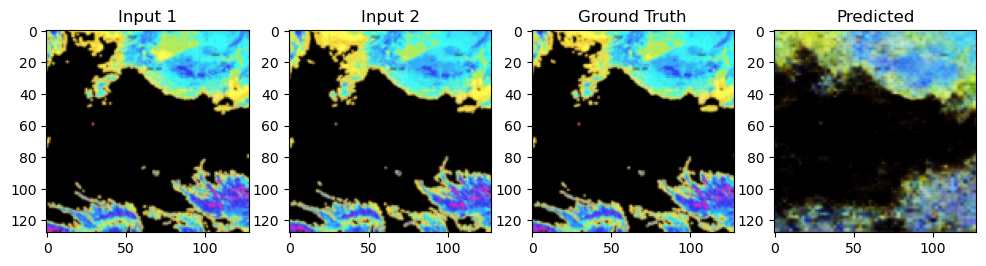

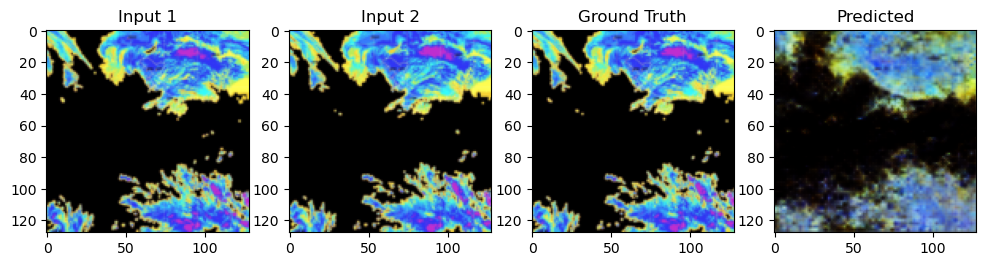

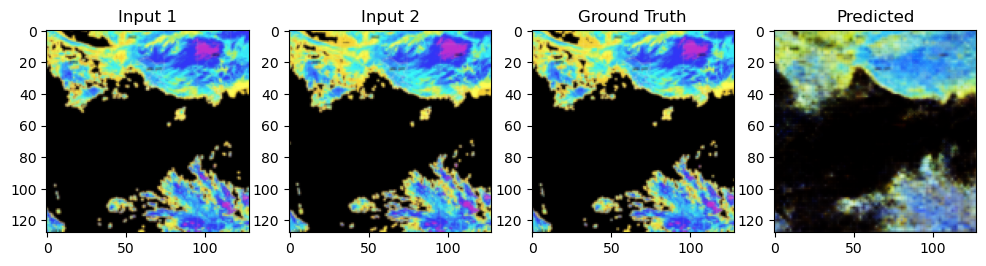

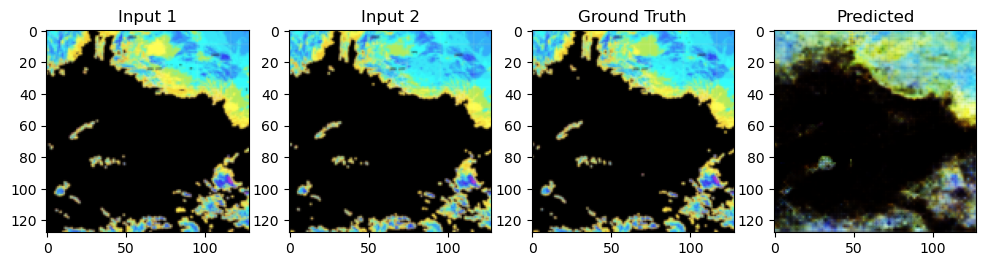

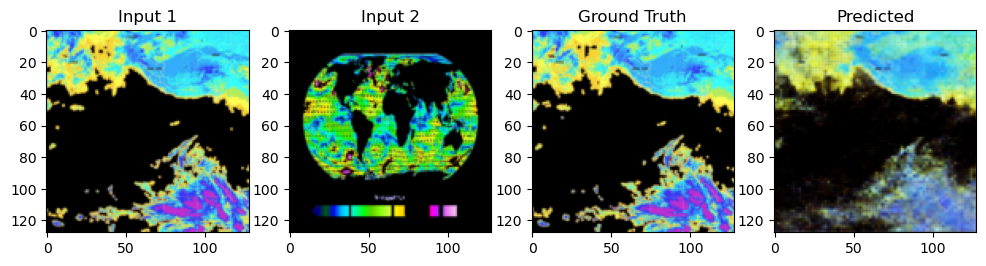

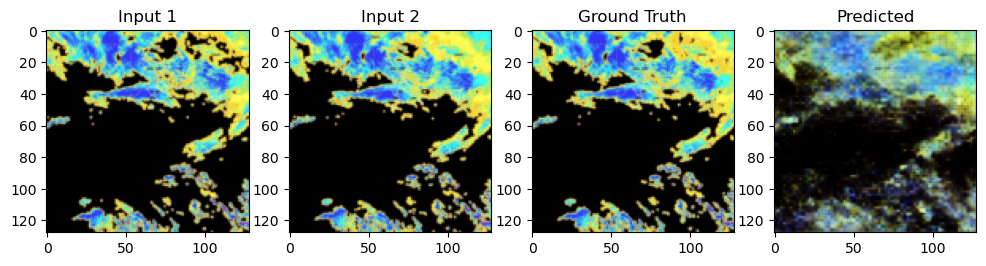

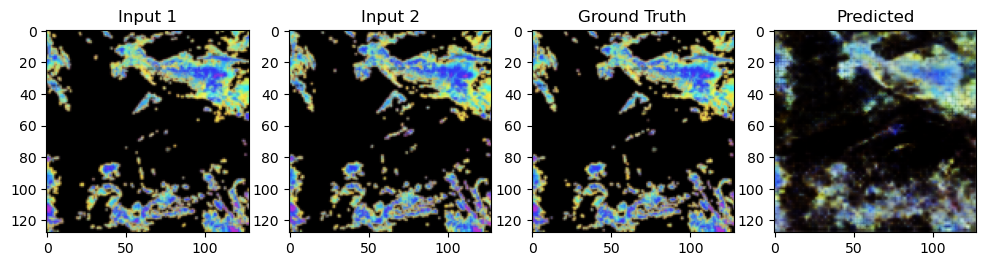

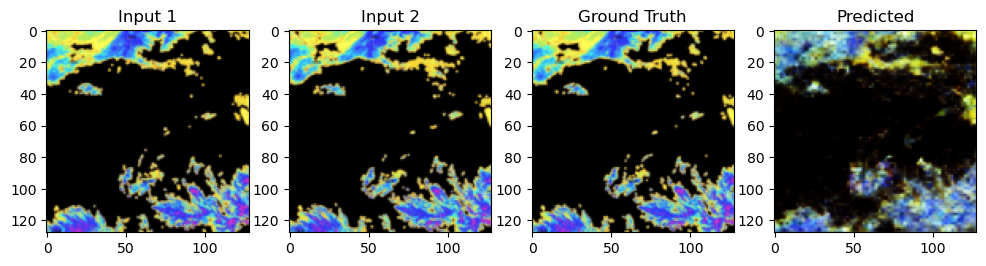

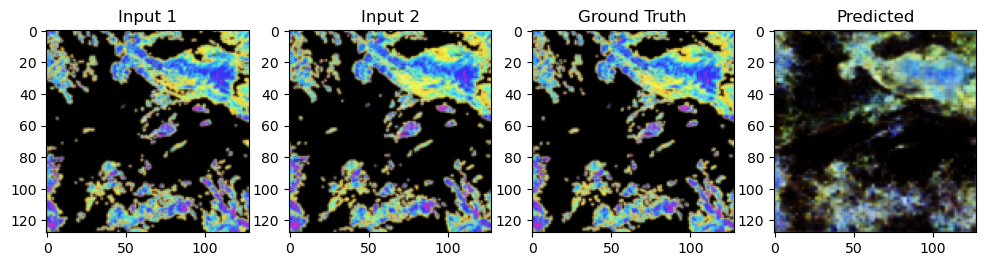

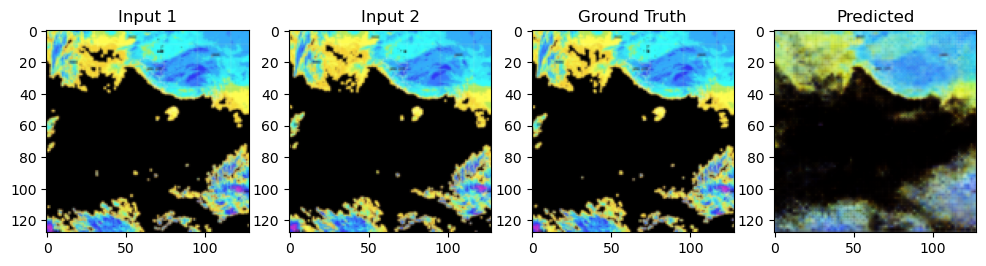

In [16]:
model.eval()
x, y = next(iter(test_loader))
x, y = x.to(device), y.to(device)
recon_y, _, _ = model(x)

for i in range(10):  # Visualize 3 examples
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 4, 1)
    plt.imshow(x[i, :3].cpu().permute(1, 2, 0))  # Input 1
    plt.title("Input 1")
    plt.subplot(1, 4, 2)
    plt.imshow(x[i, 3:6].cpu().permute(1, 2, 0))  # Input 2
    plt.title("Input 2")
    plt.subplot(1, 4, 3)
    plt.imshow(y[i].cpu().permute(1, 2, 0))  # Ground truth
    plt.title("Ground Truth")
    plt.subplot(1, 4, 4)
    plt.imshow(recon_y[i].detach().cpu().permute(1, 2, 0))  # Predicted
    plt.title("Predicted")
    plt.show()

In [17]:
def save_model(model, path="vae_model.pth"):
    torch.save(model.state_dict(), path)
    print(f"Model saved at {path}")

# Function to load the model
def load_model(model, path="vae_model.pth", device="cpu"):
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    print(f"Model loaded from {path}")
    return model

In [18]:
save_model(model)

Model saved at vae_model.pth


C:\Users\Sahil\AppData\Local\Temp\ipykernel_30640\1034546615.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vae_model.pth", map_locat

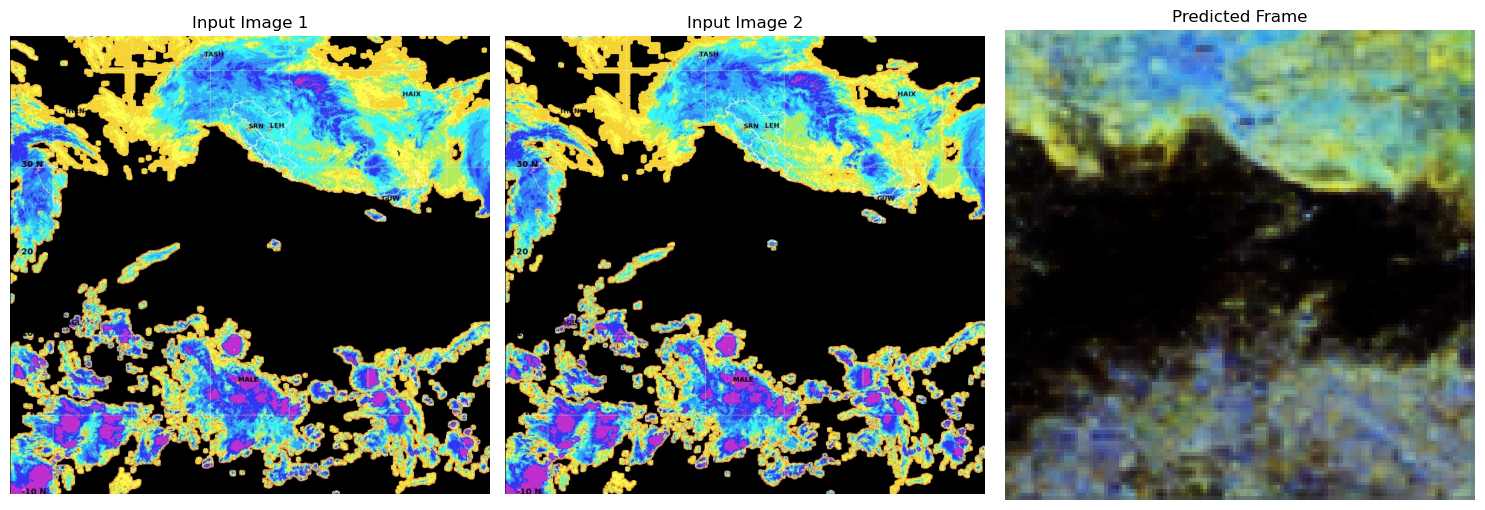

In [ ]:
import cv2
import numpy as np

# Function to generate intermediate frames and save them as a video
def generate_video(model, test_loader, video_path="generated_video.mp4", frame_count=10):
    model.eval()
    with torch.no_grad():
        # Select a batch from the test set
        x, y = next(iter(test_loader))
        x, y = x.to(device), y.to(device)

        # Initialize video writer (save as .mp4 file)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(video_path, fourcc, 20.0, (128, 128))  # 20 FPS, 128x128 resolution

        for i in range(frame_count):  # Generate 10 intermediate frames
            # Get initial two input frames
            img1 = x[i, :3].cpu().permute(1, 2, 0).numpy()  # Convert tensor to numpy array
            img2 = x[i, 3:6].cpu().permute(1, 2, 0).numpy()

            # Generate intermediate frames
            recon_y, _, _ = model(x[i:i+1])  # Predict the intermediate frame
            pred_img = recon_y.squeeze(0).cpu().permute(1, 2, 0).detach().numpy()

            # Write the generated frame to the video file
            out.write((pred_img * 255).astype(np.uint8))  # Convert from [0,1] to [0,255]

            # Visualize and save each frame (optional step for debugging)
            if i == 0:
                plt.figure(figsize=(12, 4))
                plt.subplot(1, 3, 1)
                plt.imshow(img1)
                plt.title("Input 1")
                plt.subplot(1, 3, 2)
                plt.imshow(img2)
                plt.title("Input 2")
                plt.subplot(1, 3, 3)
                plt.imshow(pred_img)
                plt.title(f"Predicted Frame {i + 1}")
                plt.show()

        # Release the video writer
        out.release()

# Generate 5 videos
for j in range(5):
    video_path = f"generated_video_{j+1}.mp4"
    generate_video(model, test_loader, video_path=video_path, frame_count=10)
    print(f"Generated video saved as {video_path}")


Shape of frame1: (128, 128, 9), frame2: (128, 128, 9)


TypeError: Invalid shape (128, 128, 9) for image data

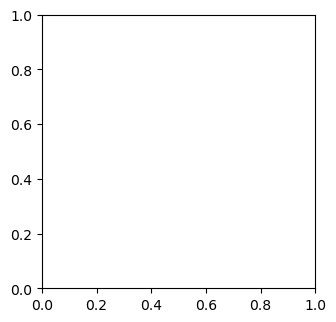

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# Function to generate intermediate frames and save them as a video
def generate_video(model, test_loader, video_path="generated_video.mp4", video_duration=60, fps=20):
    model.eval()
    with torch.no_grad():
        # Get a list of images from the test set (ensure they are loaded and shuffled)
        x, y = next(iter(test_loader))
        x, y = x.to(device), y.to(device)

        # Initialize video writer (save as .mp4 file)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(video_path, fourcc, fps, (128, 128))  # 20 FPS, 128x128 resolution

        total_frames = video_duration * fps  # Number of frames to generate
        frames_per_pair = total_frames // (len(x) - 1)  # Calculate how many frames to generate for each image pair
        
        for i in range(len(x) - 1):  # Iterate over image pairs
            frame1 = x[i].cpu().permute(1, 2, 0).numpy()  # Get the first frame
            frame2 = x[i + 1].cpu().permute(1, 2, 0).numpy()  # Get the next frame

            # Ensure both frames are of shape (128, 128, 3)
            print(f"Shape of frame1: {frame1.shape}, frame2: {frame2.shape}")

            # Predict intermediate frames and append them to the list
            for j in range(frames_per_pair):
                # Concatenate frames along the batch dimension
                input_frame = torch.cat([x[i:i+1], x[i+1:i+2]], dim=0).to(device)  # Concatenate frames
                recon_y, _, _ = model(input_frame)  # Generate predicted frame

                # Check the shape of the output from the model
                pred_img = recon_y[0].cpu().permute(1, 2, 0).detach().numpy()  # Convert to [height, width, channels]

                # Ensure that the predicted image has 3 channels (RGB)
                if pred_img.shape[2] != 3:
                    print(f"Unexpected number of channels in pred_img: {pred_img.shape[2]}")
                    continue  # Skip this frame if it doesn't have 3 channels

                # Write the generated frame to the video
                out.write((pred_img * 255).astype(np.uint8))  # Convert from [0, 1] to [0, 255]

                # Optionally, visualize the frames (for debugging)
                if j == 0:
                    plt.figure(figsize=(12, 4))
                    plt.subplot(1, 3, 1)
                    plt.imshow(frame1)
                    plt.title("Input Frame 1")
                    plt.subplot(1, 3, 2)
                    plt.imshow(frame2)
                    plt.title("Input Frame 2")
                    plt.subplot(1, 3, 3)
                    plt.imshow(pred_img)
                    plt.title(f"Predicted Frame {i + 1}-{j + 1}")
                    plt.show()

        # Release the video writer
        out.release()
        print(f"Video saved as {video_path}")

# Generate a video (e.g., for 1 minute at 20 FPS)
generate_video(model, test_loader, video_path="generated_video_1_minute.mp4", video_duration=60, fps=20)


In [57]:
import cv2
import numpy as np
import torch

# Function to generate a video with 1024 intermediate frames from one pair of images
def generate_video_with_intermediate_frames(model, test_loader, video_path="generated_video.mp4", fps=20, total_intermediate_frames=1024):
    model.eval()
    with torch.no_grad():
        # Initialize video writer (save as .mp4 file)
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(video_path, fourcc, fps, (128, 128))  # 20 FPS, 128x128 resolution

        # Iterate through batches of frames in the test set
        for x, _ in test_loader:  # Automatically iterate through DataLoader batches
            x = x.to(device)

            # Pick a pair of images (e.g., first and second image in the batch)
            frame1 = x[0]  # First frame in the pair
            frame2 = x[1]  # Second frame in the pair

            # Add the first frame to the video (write it to the video file)
            pred_img = frame1.cpu().permute(1, 2, 0).detach().numpy()  # Convert from [C, H, W] to [H, W, C]
            out.write((pred_img * 255).astype(np.uint8))

            # Generate 1024 intermediate frames between frame1 and frame2
            for k in range(total_intermediate_frames):
                # Concatenate frames for input to the model (size: [batch_size, channels, height, width])
                input_frame = torch.cat([frame1.unsqueeze(0), frame2.unsqueeze(0)], dim=0).to(device)

                # Generate the predicted intermediate frame
                recon_y, _, _ = model(input_frame)

                # Extract the first predicted frame from the batch (since we only need the first one)
                recon_y = recon_y[0]  # Get the prediction for the first pair of frames

                # Check if recon_y has the correct shape [C, H, W] and permute it
                if recon_y.dim() == 3:  # [C, H, W]
                    pred_img = recon_y.permute(1, 2, 0).cpu().detach().numpy()  # Convert from [C, H, W] to [H, W, C]
                else:
                    print(f"Unexpected shape: {recon_y.shape}")
                    continue

                # Write the intermediate frame to the video
                out.write((pred_img * 255).astype(np.uint8))

            # Add the second frame (frame2) to the video
            pred_img = frame2.cpu().permute(1, 2, 0).detach().numpy()
            out.write((pred_img * 255).astype(np.uint8))

            # Once we've processed the first batch, break the loop since we only want to process one pair
            break

        # Release the video writer
        out.release()
        print(f"Video saved as {video_path}")

# Generate the video with 1024 intermediate frames between one pair of images
generate_video_with_intermediate_frames(model, test_loader, video_path="generated_video_with_intermediate.mp4", fps=20, total_intermediate_frames=1024)


Video saved as generated_video_with_intermediate.mp4
